# Grupo 1 | MCDI501 - Estadística Computacional para la Toma de Decisiones

## Integrantes
- Pablo Ignacio Balbontin Constenla @pabbalbontin-maker
- Melany Esmeralda Reyes Leiva @melanyreyesy
- Ingeborg Andrea Munoz Carnot @dark452
- Mario Alejandro Lopez Pulgar @malp2203

## Descripción del problema - Fase 2 Análisis Exploratorio e Inferencial

*Proyecto*: Predicción de la Deserción y el Éxito Académico de los Estudiantes

El dataset elegido contiene información socioeconómica, académica y demográfica de estudiantes de educación superior en Portugal. El objetivo del proyecto es predecir si un estudiante se graduará, abandonará o permanecerá matriculado, lo que permite implementar intervenciones tempranas de retención.

**Dataset:** Predict Students' Dropout and Academic Success  


## Configuración del entorno

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad
np.random.seed(42)

# Estilo gráfico
plt.rcParams.update({'font.size': 10, 'figure.dpi': 120})
sns.set_style('whitegrid')

# Paleta de colores
COLORS_TARGET = {'Graduate': '#2ca02c', 'Dropout': '#d62728', 'Enrolled': '#1f77b4'}
ORDER_TARGET  = ['Graduate', 'Enrolled', 'Dropout']

# Paleta de colores para histogramas
HIST_COLORS = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#e91e63']

print('Entorno configurado.')

Entorno configurado.


## Sección 1 - Preparación y Carga de Datos

Carga del dataset, verificación de estructura, tipos de variables, identificación, documentación de faltantes, duplicados e inconsistencias, limpieza básica y reporte inicial de calidad.

### 1.1 Carga del dataset

In [2]:
def load_data(file_path: str) -> pd.DataFrame:
    """Carga dataset raw, desde un archivo CSV

    Parámetros
    ----------
    file_path : str
        Ruta del archivo CSV utilizado como entrada.

    Retorno
    -------
    pd.DataFrame
        Datos cargados en un DataFrame.

    Excepción
    ---------
    FileNotFoundError
        Si la ruta al archivo CSV no existe. Se muestra un mensaje de error
    """
    try:
        df = pd.read_csv(file_path, sep=';')
    except FileNotFoundError:
        raise FileNotFoundError(
            f"No se encontró el archivo '{file_path}'."
            "Verificar que el archivo CSV se encuentre en data/raw."
        )
    return df

In [3]:
df = load_data('../data/raw/predict_students_dropout_and_academic_success.csv')
# Limpieza de nombres: eliminar espacios y tabs residuales
df.columns = [c.strip() for c in df.columns]
print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')

print(f'\nPrimeras 3 filas:')
df.head(3)

Dataset cargado: 4,424 filas x 37 columnas

Primeras 3 filas:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout


### 1.2 Verificación de estructura y clasificación de variables

In [4]:
# Clasificación semántica de las variables
# Nota: muchas variables codificadas como int son categorías ordinales/nominales

NUMERIC_CONTIN = [
    'Previous qualification (grade)', 'Admission grade',
    'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

NUMERIC_DISCR = [
    'Age at enrollment',
    'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)',
    'Application order'
]

CATEG_NOMINAL = ['Marital status', 'Application mode', 'Course', 'Nacionality',
                 "Mother's qualification", "Father's qualification",
                 "Mother's occupation", "Father's occupation", 'Previous qualification']

CATEG_BINARY  = ['Daytime/evening attendance', 'Displaced', 'Educational special needs',
                 'Debtor', 'Tuition fees up to date', 'Gender',
                 'Scholarship holder', 'International']

TARGET = 'Target'

print('*** Clasificación de variables ***')
print(f'  Numéricas continuas : {len(NUMERIC_CONTIN)}')
print(f'  Numéricas discretas : {len(NUMERIC_DISCR)}')
print(f'  Categóricas nominales: {len(CATEG_NOMINAL)}')
print(f'  Categóricas binarias : {len(CATEG_BINARY)}')
print(f'  Variable objetivo    : {TARGET}')
print(f'\nTotal variables analizadas: {df.shape[1]}')

*** Clasificación de variables ***
  Numéricas continuas : 7
  Numéricas discretas : 6
  Categóricas nominales: 9
  Categóricas binarias : 8
  Variable objetivo    : Target

Total variables analizadas: 37


### 1.3 Diagnóstico de calidad: valores faltantes, duplicados e inconsistencias


In [5]:
# *** Valores faltantes ***
nulls = df.isnull().sum()
null_report = nulls[nulls > 0]

print('Valores faltantes por columna:')
if null_report.empty:
    print('  ==> Sin valores faltantes. Dataset completo.')
else:
    print(null_report)

# *** Duplicados ***
n_dup = df.duplicated().sum()
print(f'\nRegistros duplicados: {n_dup}')
if n_dup == 0:
    print('  ==> Sin duplicados.')

# *** Rangos y posibles inconsistencias ***
print('\n*** Rangos de variables numéricas continuas ***')
for v in NUMERIC_CONTIN:
    print(f'  {v}: [{df[v].min():.2f}, {df[v].max():.2f}]')

# Notas fuera de rango esperado [0, 20]
grade_cols = ['Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']
for gc in grade_cols:
    out = ((df[gc] < 0) | (df[gc] > 20)).sum()
    print(f'  Valores fuera de [0,20] en "{gc}": {out}')

# Notas de admisión [95, 190]: rango válido del sistema ENES
out_adm = ((df['Admission grade'] < 95) | (df['Admission grade'] > 190)).sum()
print(f'  Valores fuera de [95,190] en "Admission grade": {out_adm}')

Valores faltantes por columna:
  ==> Sin valores faltantes. Dataset completo.

Registros duplicados: 0
  ==> Sin duplicados.

*** Rangos de variables numéricas continuas ***
  Previous qualification (grade): [95.00, 190.00]
  Admission grade: [95.00, 190.00]
  Curricular units 1st sem (grade): [0.00, 18.88]
  Curricular units 2nd sem (grade): [0.00, 18.57]
  Unemployment rate: [7.60, 16.20]
  Inflation rate: [-0.80, 3.70]
  GDP: [-4.06, 3.51]
  Valores fuera de [0,20] en "Curricular units 1st sem (grade)": 0
  Valores fuera de [0,20] en "Curricular units 2nd sem (grade)": 0
  Valores fuera de [95,190] en "Admission grade": 0


### 1.4 Reporte de calidad consolidado


In [6]:
print('═'*55)
print('   REPORTE INICIAL DE CALIDAD DEL DATASET')
print('═'*55)
print(f'  Registros totales          : {len(df):,}')
print(f'  Variables totales          : {df.shape[1]}')
print(f'  Valores faltantes          : {df.isnull().sum().sum()} (0.0%)')
print(f'  Registros duplicados       : {df.duplicated().sum()}')
print(f'  Variables continuas        : {len(NUMERIC_CONTIN)}')
print(f'  Variables discretas        : {len(NUMERIC_DISCR)}')
print(f'  Variables categóricas      : {len(CATEG_NOMINAL) + len(CATEG_BINARY)}')
print(f'  Variable objetivo (Target) : 3 clases - Dropout, Enrolled, Graduate')
print('═'*55)
print('  ==> El dataset no requiere imputación ni eliminación de filas.')
print('  ==> Se realizó limpieza de espacios en nombres de columnas.')
print('  ==> Rangos de variables dentro de valores esperados para el dominio.')

═══════════════════════════════════════════════════════
   REPORTE INICIAL DE CALIDAD DEL DATASET
═══════════════════════════════════════════════════════
  Registros totales          : 4,424
  Variables totales          : 37
  Valores faltantes          : 0 (0.0%)
  Registros duplicados       : 0
  Variables continuas        : 7
  Variables discretas        : 6
  Variables categóricas      : 17
  Variable objetivo (Target) : 3 clases - Dropout, Enrolled, Graduate
═══════════════════════════════════════════════════════
  ==> El dataset no requiere imputación ni eliminación de filas.
  ==> Se realizó limpieza de espacios en nombres de columnas.
  ==> Rangos de variables dentro de valores esperados para el dominio.


---
## Sección 2 — Análisis Exploratorio de Datos

Estadística descriptiva de variables numéricas y categóricas con visualizaciones; análisis bivariado con correlaciones e interpretación en el contexto del problema.

### 2.1 Distribución de la variable objetivo

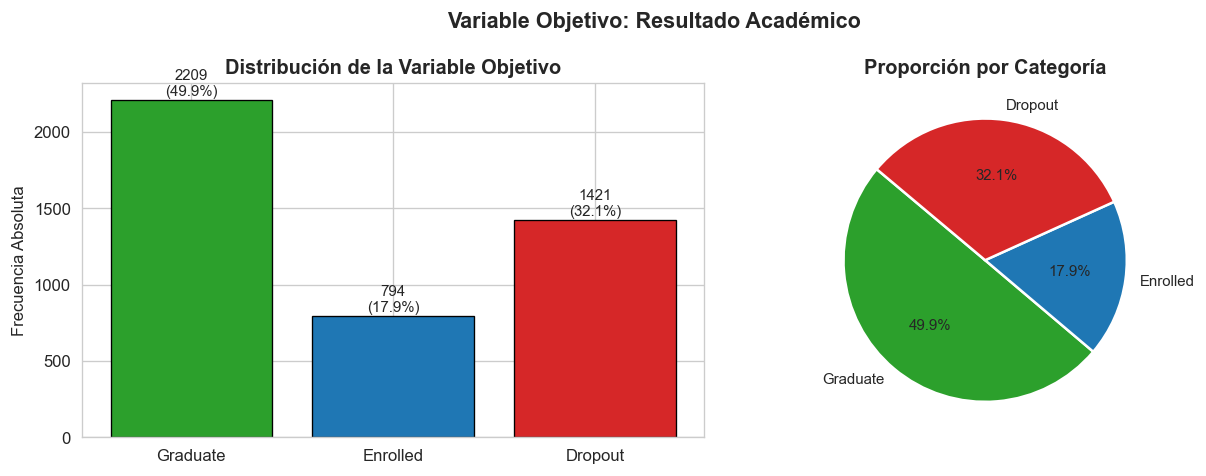


Tabla de frecuencias:
             n      %
Target               
Graduate  2209  49.93
Dropout   1421  32.12
Enrolled   794  17.95


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

vc = df['Target'].value_counts()
axes[0].bar(ORDER_TARGET, [vc[t] for t in ORDER_TARGET],
            color=[COLORS_TARGET[t] for t in ORDER_TARGET],
            edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribución de la Variable Objetivo', fontweight='bold')
axes[0].set_ylabel('Frecuencia Absoluta')
for i, t in enumerate(ORDER_TARGET):
    axes[0].text(i, vc[t]+30, f'{vc[t]}\n({vc[t]/len(df)*100:.1f}%)', ha='center', fontsize=9)

sizes = [vc[t] for t in ORDER_TARGET]
axes[1].pie(sizes, labels=ORDER_TARGET, autopct='%1.1f%%',
            colors=[COLORS_TARGET[t] for t in ORDER_TARGET],
            startangle=140, textprops={'fontsize': 9},
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporción por Categoría', fontweight='bold')

plt.suptitle('Variable Objetivo: Resultado Académico', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig1_distribucion_target.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nTabla de frecuencias:')
freq_df = pd.DataFrame({'n': vc, '%': (vc/len(df)*100).round(2)})
print(freq_df)

**Interpretación:** El dataset presenta una distribución desequilibrada. La categoría *Graduate* concentra el 49.9% de los registros (n=2,209), seguida por *Dropout* con el 32.1% (n=1,421) y *Enrolled* con el 17.9% (n=794). Esta distribución implica que cualquier modelo predictivo deberá considerar estrategias de balanceo de clases. El alto porcentaje de abandono (≈1 de cada 3 estudiantes) confirma la relevancia del problema de investigación.

### 2.2 Estadística descriptiva de variables numéricas

In [8]:
ALL_NUM = ['Previous qualification (grade)', 'Admission grade',
           'Age at enrollment', 'Curricular units 1st sem (grade)',
           'Curricular units 2nd sem (grade)', 'Unemployment rate',
           'Inflation rate', 'GDP']

desc = df[ALL_NUM].describe().T
desc['cv'] = (desc['std'] / desc['mean'] * 100).round(2)
desc['skew'] = df[ALL_NUM].skew().round(3)
desc['kurtosis'] = df[ALL_NUM].kurtosis().round(3)
desc = desc[['count','mean','std','cv','min','25%','50%','75%','max','skew','kurtosis']]
desc.columns = ['n','Media','Desv.Est.','CV(%)','Mín','Q1','Mediana','Q3','Máx','Asimetría','Curtosis']
desc.round(3)

,n,Media,Desv.Est.,CV(%),Mín,Q1,Mediana,Q3,Máx,Asimetría,Curtosis
Previous qualification (grade),4424.0,132.613,13.188,9.94,95.00,125.00,133.100,140.000,190.000,0.313,0.968
Admission grade,4424.0,126.978,14.482,11.41,95.00,117.90,126.100,134.800,190.000,0.531,0.663
Age at enrollment,4424.0,23.265,7.588,32.61,17.00,19.00,20.000,25.000,70.000,2.055,4.127
Curricular units 1st sem (grade),4424.0,10.641,4.844,45.52,0.00,11.00,12.286,13.400,18.875,-1.568,0.908
Curricular units 2nd sem (grade),4424.0,10.230,5.211,50.94,0.00,10.75,12.200,13.333,18.571,-1.314,0.067
Unemployment rate,4424.0,11.566,2.664,23.03,7.60,9.40,11.100,13.900,16.200,0.212,-0.996
Inflation rate,4424.0,1.228,1.383,112.60,-0.80,0.30,1.400,2.600,3.700,0.252,-1.039
GDP,4424.0,0.002,2.270,115295.00,-4.06,-1.70,0.320,1.790,3.510,-0.394,-1.002


### 2.3 Histogramas de variables numéricas

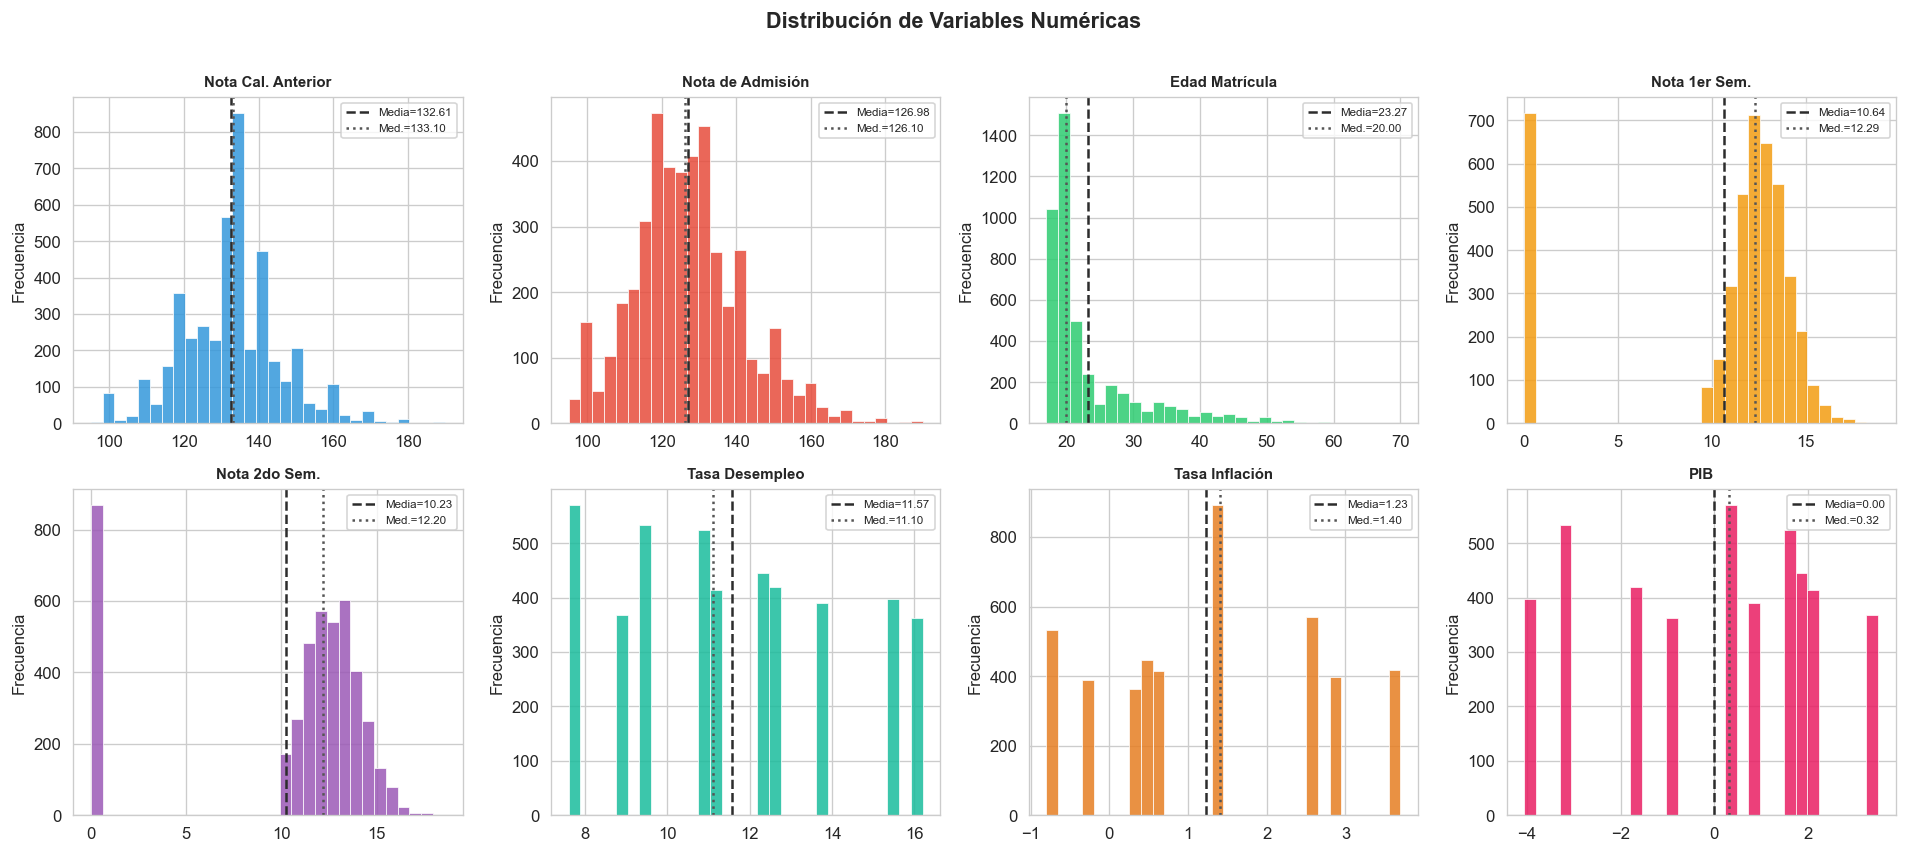

In [9]:
labels_map = {
    'Previous qualification (grade)': 'Nota Cal. Anterior',
    'Admission grade': 'Nota de Admisión',
    'Age at enrollment': 'Edad Matrícula',
    'Curricular units 1st sem (grade)': 'Nota 1er Sem.',
    'Curricular units 2nd sem (grade)': 'Nota 2do Sem.',
    'Unemployment rate': 'Tasa Desempleo',
    'Inflation rate': 'Tasa Inflación',
    'GDP': 'PIB'
}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, var in enumerate(ALL_NUM):
    color = HIST_COLORS[i]
    axes[i].hist(df[var], bins=30, color=color, edgecolor='white',
                 linewidth=0.5, alpha=0.85)
    axes[i].axvline(df[var].mean(), color='#2c2c2c', linestyle='--',
                    linewidth=1.5, label=f'Media={df[var].mean():.2f}')
    axes[i].axvline(df[var].median(), color='#555555', linestyle=':',
                    linewidth=1.5, label=f'Med.={df[var].median():.2f}')
    axes[i].set_title(labels_map[var], fontweight='bold', fontsize=9)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=7)

plt.suptitle('Distribución de Variables Numéricas', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/fig2_histogramas.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretación:** Las notas de admisión y calificación previa muestran distribuciones aproximadamente simétricas con leve asimetría negativa, lo que indica que la mayoría de los estudiantes ingresan con notas en el rango medio-alto (120-140 sobre 190). La *Edad al matricularse* presenta asimetría positiva marcada (cola hacia la derecha), con mayoría de estudiantes jóvenes (moda ≈ 19-20 años) pero presencia de estudiantes adultos (hasta 70 años). Las tasas macroeconómicas (desempleo, inflación, PIB) reflejan el contexto económico portugués del período cubierto por el dataset.

### 2.4 Variables categóricas: frecuencias y gráficos

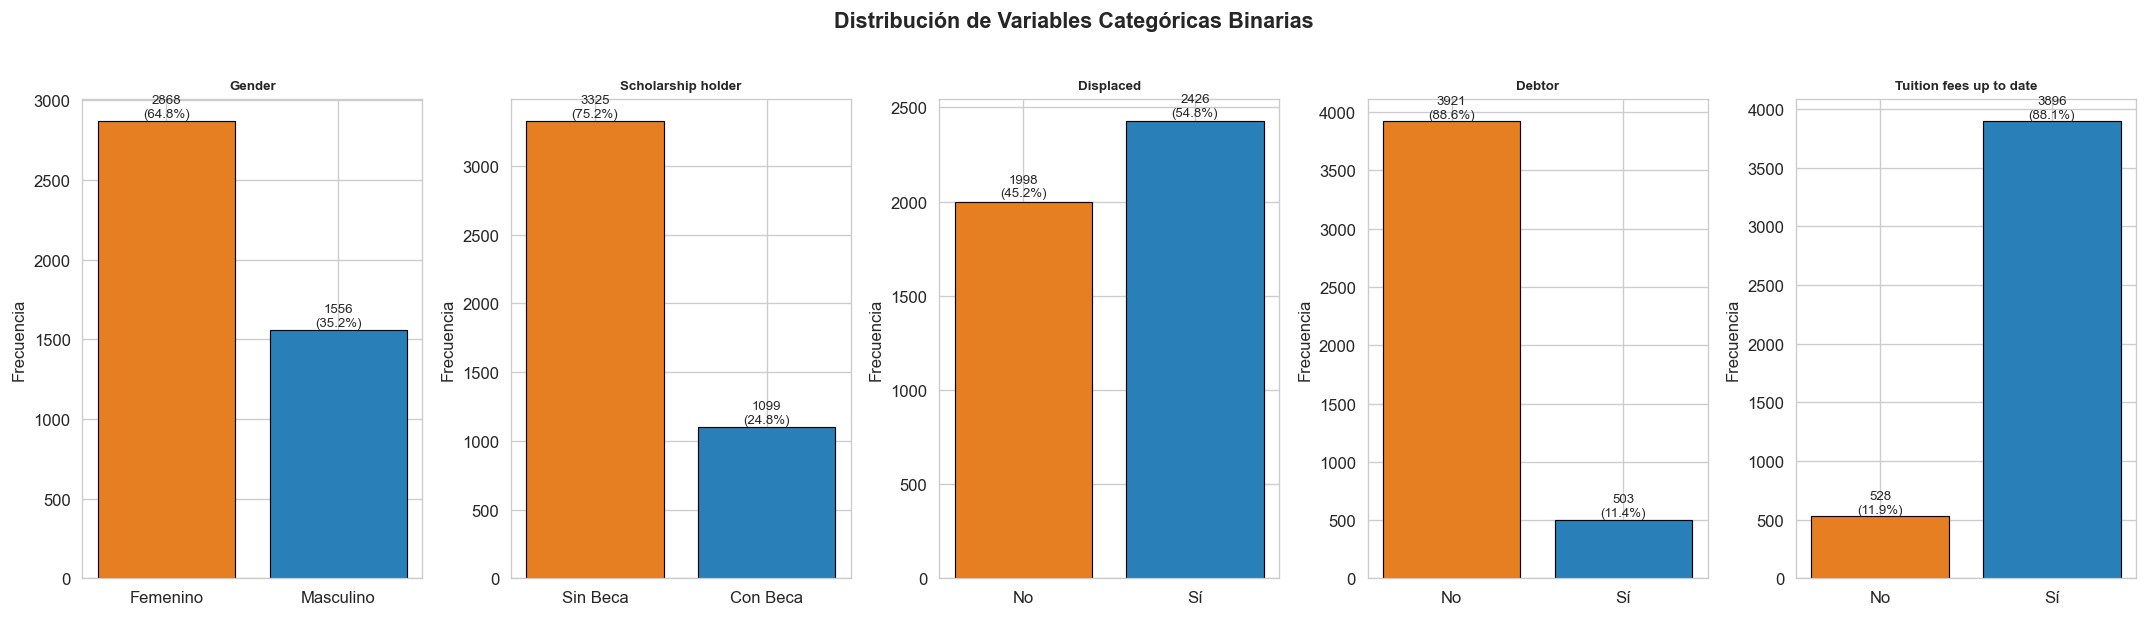


Frecuencias absolutas y relativas:

Gender:
  Femenino: n=2868 (64.8%)
  Masculino: n=1556 (35.2%)

Scholarship holder:
  Sin Beca: n=3325 (75.2%)
  Con Beca: n=1099 (24.8%)

Displaced:
  No: n=1998 (45.2%)
  Sí: n=2426 (54.8%)

Debtor:
  No: n=3921 (88.6%)
  Sí: n=503 (11.4%)

Tuition fees up to date:
  No: n=528 (11.9%)
  Sí: n=3896 (88.1%)


In [10]:
cat_binary = ['Gender', 'Scholarship holder', 'Displaced', 'Debtor', 'Tuition fees up to date']
cat_labels = ['Género\n(0=F, 1=M)', 'Becado', 'Desplazado', 'Deudor', 'Matrícula al Día']
cat_map = {
    'Gender': {0: 'Femenino', 1: 'Masculino'},
    'Scholarship holder': {0: 'Sin Beca', 1: 'Con Beca'},
    'Displaced': {0: 'No', 1: 'Sí'},
    'Debtor': {0: 'No', 1: 'Sí'},
    'Tuition fees up to date': {0: 'No', 1: 'Sí'}
}
BAR_COLORS = ['#e67e22', '#2980b9']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, (var, lab) in enumerate(zip(cat_binary, cat_labels)):
    vc2 = df[var].value_counts().sort_index()
    labels_bar = [cat_map[var].get(k, str(k)) for k in vc2.index]
    axes[i].bar(labels_bar, vc2.values,
                color=BAR_COLORS, edgecolor='black', linewidth=0.7)
    axes[i].set_title(var, fontweight='bold', fontsize=8)
    axes[i].set_ylabel('Frecuencia')
    for j, v in enumerate(vc2.values):
        axes[i].text(j, v+30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=8)

plt.suptitle('Distribución de Variables Categóricas Binarias', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/fig5_categoricas.png', bbox_inches='tight', dpi=150)
plt.show()

# Tabla de frecuencias
print('\nFrecuencias absolutas y relativas:')
for var in cat_binary:
    vc3 = df[var].value_counts().sort_index()
    pct = (vc3/len(df)*100).round(1)
    print(f'\n{var}:')
    for k in vc3.index:
        print(f'  {cat_map[var].get(k,k)}: n={vc3[k]} ({pct[k]}%)')

### 2.5 Análisis bivariado: variables clave por resultado académico

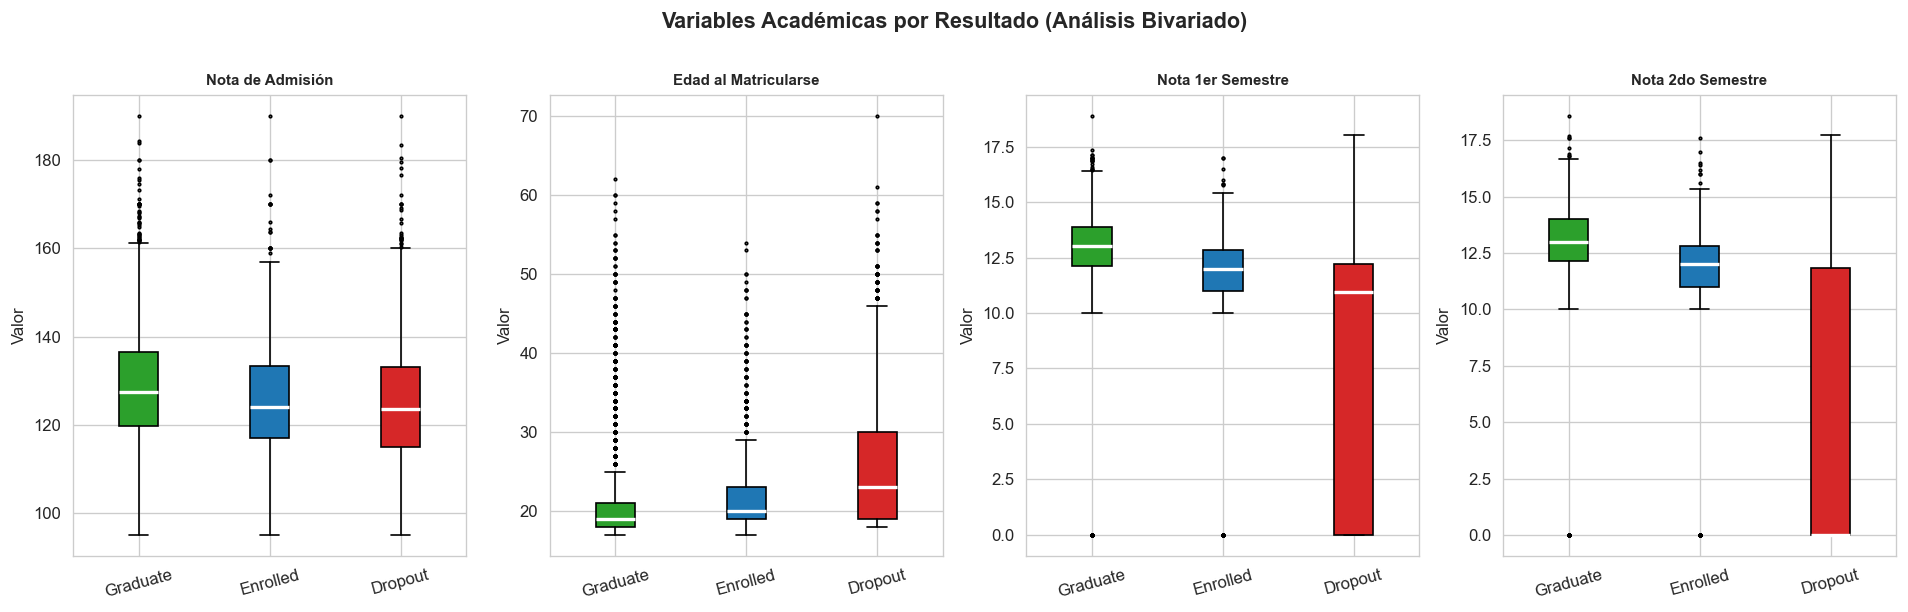


Medias por grupo:
Target                            Dropout  Enrolled  Graduate
Admission grade                   124.961   125.534   128.794
Age at enrollment                  26.069    22.369    21.784
Curricular units 1st sem (grade)    7.257    11.125    12.644
Curricular units 2nd sem (grade)    5.899    11.117    12.697


In [11]:
key_vars = ['Admission grade', 'Age at enrollment',
            'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']
key_labs = ['Nota de Admisión', 'Edad al Matricularse',
             'Nota 1er Semestre', 'Nota 2do Semestre']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
palette = COLORS_TARGET

for i, (var, lab) in enumerate(zip(key_vars, key_labs)):
    data_plot = [df[df['Target']==t][var].values for t in ORDER_TARGET]
    bp = axes[i].boxplot(data_plot, labels=ORDER_TARGET, patch_artist=True,
                         medianprops={'color': 'white', 'linewidth': 2},
                         whiskerprops={'color': 'black'},
                         capprops={'color': 'black'},
                         flierprops={'marker': '.', 'markersize': 3, 'color': '#999999'})
    for patch, t in zip(bp['boxes'], ORDER_TARGET):
        patch.set_facecolor(palette[t])
    axes[i].set_title(lab, fontweight='bold', fontsize=9)
    axes[i].set_ylabel('Valor')
    axes[i].tick_params(axis='x', labelrotation=15)

plt.suptitle('Variables Académicas por Resultado (Análisis Bivariado)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/fig3_boxplots_target.png', bbox_inches='tight', dpi=150)
plt.show()

# Medias por grupo
print('\nMedias por grupo:')
print(df.groupby('Target')[key_vars].mean().round(3).T.to_string())

**Interpretación:** Los boxplots revelan patrones consistentes y estadísticamente relevantes:

- **Nota de Admisión:** Los graduados presentan notas de admisión superiores (μ≈128.8) respecto a los desertores (μ≈124.9), diferencia que se analizará formalmente en la Sección 4.
- **Edad:** Los desertores tienen una edad de matrícula mayor (μ≈26.1 años) comparado con los graduados (μ≈21.8 años), sugiriendo que los estudiantes adultos enfrentan mayores barreras para completar sus estudios.
- **Notas de 1° y 2° semestre:** Este es el factor más discriminante. Los graduados obtienen notas significativamente más altas (mediana ≈12-13), mientras que los desertores concentran notas cercanas a 0, indicando que muchos abandonan sin completar evaluaciones.
- El rendimiento del 1° semestre actúa como un indicador temprano confiable del resultado final.

### 2.6 Matriz de correlación

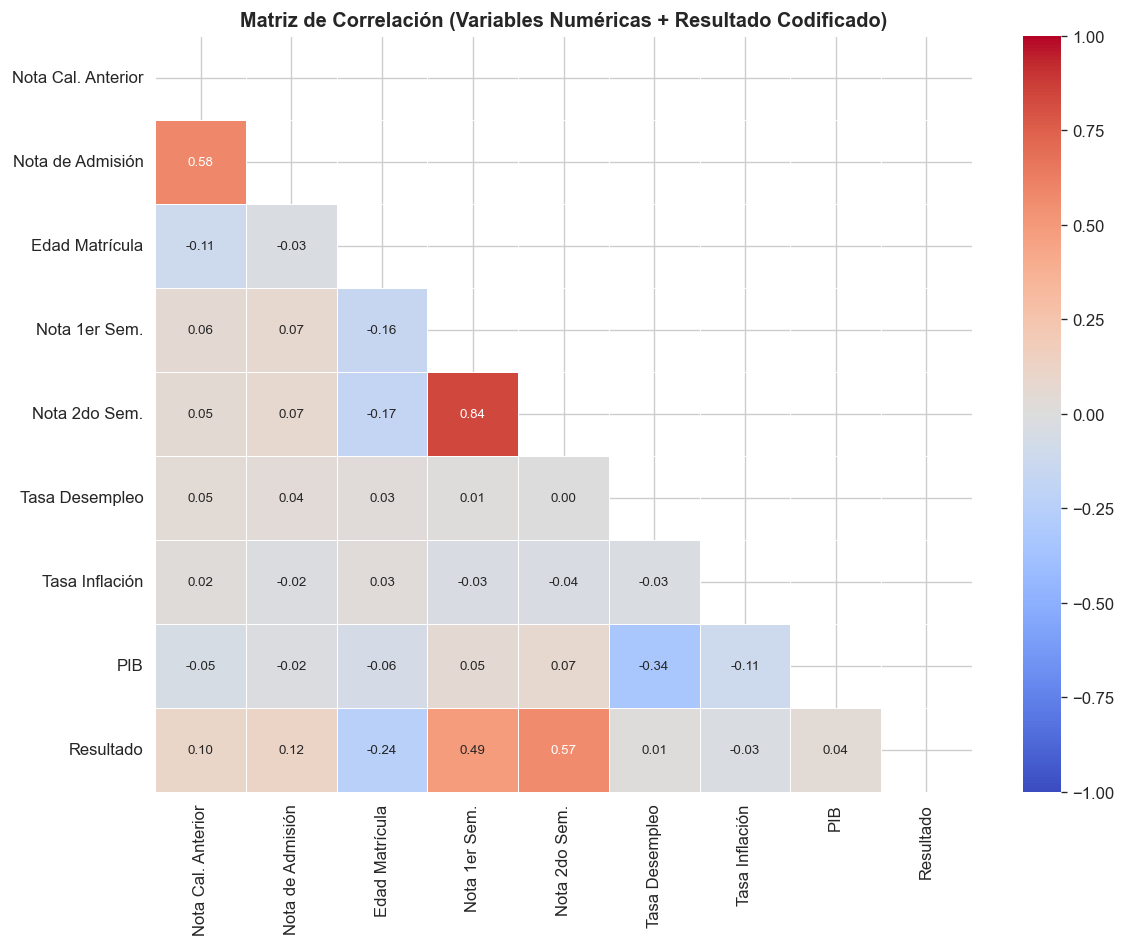


Correlaciones con Target_num (ordenadas):
  Nota 2do Sem.                 : r = +0.5668
  Nota 1er Sem.                 : r = +0.4852
  Nota de Admisión              : r = +0.1209
  Nota Cal. Anterior            : r = +0.1038
  PIB                           : r = +0.0441
  Tasa Desempleo                : r = +0.0086
  Tasa Inflación                : r = -0.0269
  Edad Matrícula                : r = -0.2434


In [12]:
df_enc = df.copy()
df_enc['Target_num'] = df_enc['Target'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})

corr_vars = ALL_NUM + ['Target_num']
corr_labels = [labels_map[v] for v in ALL_NUM] + ['Resultado']
corr_matrix = df_enc[corr_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, ax=ax,
            linewidths=0.5,
            xticklabels=corr_labels, yticklabels=corr_labels,
            annot_kws={'size': 8})
ax.set_title('Matriz de Correlación (Variables Numéricas + Resultado Codificado)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/fig4_correlacion.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nCorrelaciones con Target_num (ordenadas):')
corr_target = corr_matrix['Target_num'].drop('Target_num').sort_values(ascending=False)
for var, r in corr_target.items():
    print(f'  {labels_map.get(var, var):30s}: r = {r:+.4f}')

**Interpretación:** Las notas del 1° y 2° semestre son las variables con mayor correlación positiva con el resultado (r=0.49 y r=0.57 respectivamente), confirmando que el rendimiento académico semestral es el predictor más fuerte de graduación. La edad al matricularse presenta correlación negativa moderada (r=−0.24), indicando que mayor edad se asocia a mayor riesgo de abandono. Las variables macroeconómicas (desempleo, inflación, PIB) muestran correlaciones muy débiles con el resultado individual, lo que sugiere que factores académicos internos dominan sobre el contexto económico externo.

---
## Sección 3 — Estimación de Parámetros

Para al menos 3 variables numéricas relevantes: estimación puntual e intervalos de confianza al 95%; interpretación, justificación de métodos y discusión de limitaciones.

### 3.1 Estimaciones puntuales e intervalos de confianza al 95%

In [13]:
from scipy.stats import t as t_dist

CI_VARS = [
    ('Admission grade',                    'Nota de Admisión'),
    ('Age at enrollment',                  'Edad al Matricularse'),
    ('Curricular units 1st sem (grade)',   'Nota 1er Semestre'),
    ('GDP',                                'PIB')
]

print(f'Nivel de confianza: 95% | Método: t-Student (n grande ≈ Normal)')
print(f'Justificación: Se usa la distribución t de Student por ser el método')
print(f' exacto para medias con varianza desconocida, válido para cualquier n.')
print('='*80)
print(f"{'Variable':<35} {'n':>6} {'Media':>10} {'Desv.Est.':>10} {'IC 95% Inf':>12} {'IC 95% Sup':>12}")
print('-'*80)

ci_results = []
for var, lab in CI_VARS:
    data = df[var].dropna()
    n = len(data)
    media = data.mean()
    std   = data.std(ddof=1)
    se    = std / np.sqrt(n)
    ci    = t_dist.interval(0.95, df=n-1, loc=media, scale=se)
    ci_results.append((lab, n, media, std, se, ci[0], ci[1]))
    print(f'{lab:<35} {n:>6} {media:>10.4f} {std:>10.4f} {ci[0]:>12.4f} {ci[1]:>12.4f}')

print('='*80)

Nivel de confianza: 95% | Método: t-Student (n grande ≈ Normal)
Justificación: Se usa la distribución t de Student por ser el método
 exacto para medias con varianza desconocida, válido para cualquier n.
Variable                                 n      Media  Desv.Est.   IC 95% Inf   IC 95% Sup
--------------------------------------------------------------------------------
Nota de Admisión                      4424   126.9781    14.4820     126.5513     127.4050
Edad al Matricularse                  4424    23.2651     7.5878      23.0415      23.4888
Nota 1er Semestre                     4424    10.6408     4.8437      10.4981      10.7836
PIB                                   4424     0.0020     2.2699      -0.0649       0.0689


### 3.2 Visualización de intervalos de confianza

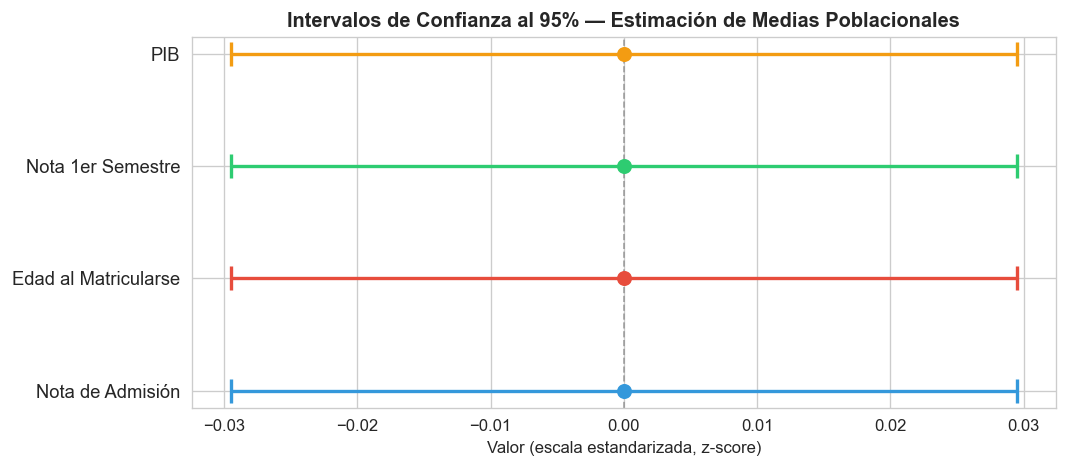

In [14]:
# Forest plot normalizado
from scipy.stats import t as t_dist

z_vars, z_means_list, z_lows_list, z_highs_list = [], [], [], []
for var, lab in CI_VARS:
    data = df[var].dropna()
    z = (data - data.mean()) / data.std()
    n = len(z); m = z.mean(); s = z.std(ddof=1)
    se = s / np.sqrt(n)
    ci = t_dist.interval(0.95, df=n-1, loc=m, scale=se)
    z_vars.append(lab)
    z_means_list.append(m)
    z_lows_list.append(m - ci[0])
    z_highs_list.append(ci[1] - m)

FOREST_COLORS = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

fig, ax = plt.subplots(figsize=(9, 4))
y_pos = range(len(z_vars))
for idx, (ym, yl, yh, col) in enumerate(zip(z_means_list, z_lows_list, z_highs_list, FOREST_COLORS)):
    ax.errorbar(ym, idx, xerr=[[yl], [yh]],
                fmt='o', color=col, ecolor=col,
                capsize=7, capthick=2, markersize=8, linewidth=2)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(z_vars, fontsize=11)
ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Valor (escala estandarizada, z-score)', fontsize=10)
ax.set_title('Intervalos de Confianza al 95% — Estimación de Medias Poblacionales',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig6_intervalos_confianza.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.3 Interpretación y justificación

**Método utilizado:** Intervalo de confianza basado en la distribución *t* de Student, ya que la varianza poblacional es desconocida. Para n=4,424, el cuantil t se aproxima al cuantil normal estándar, pero se mantiene el método exacto.

**Resultados clave:**

- **Nota de Admisión** [126.55, 127.41]: El 95% de los IC construidos con muestras del mismo tamaño contendrían la verdadera media poblacional. El rango estrecho (±0.43 puntos) refleja la alta precisión derivada del gran tamaño muestral. Se estima que la nota promedio de ingreso en la institución ronda los 127 puntos sobre 190.

- **Edad al matricularse** [23.04, 23.49]: La edad media de matriculación es ≈23.3 años. El IC confirma que la población estudiada es predominantemente joven, aunque la desviación estándar de ≈7.6 años indica heterogeneidad etaria relevante.

- **Nota 1° Semestre** [10.50, 10.78]: La media teórica esperada en una escala de 0-20 sería 10. El IC sitúa la media apenas por encima de 10, con valores más bajos de lo esperado para una población universitaria. Esto podría reflejar que muchos desertores obtienen 0 en sus evaluaciones, deprimiendo la media global.

- **PIB** [-0.06, 0.07]: El IC incluye el cero, lo que indica que el PIB medio durante el período de estudio no difiere significativamente de cero en términos de crecimiento. Esto refleja la volatilidad económica del contexto portugués post-crisis 2008.

**Limitaciones:** 
- 1. Los IC asumen que los datos corresponden a una muestra aleatoria de la población, si el dataset tiene sesgo de selección institucional, las estimaciones pueden no generalizarse. 
- 2. Para variables con distribución marcadamente asimétrica (como Edad), el IC para la media puede no ser el estadístico más informativo, sería preferible complementar con IC para la mediana.

---
## Sección 4 — Pruebas de Hipótesis

 Al menos 2 pruebas pertinentes al problema: formulación de H₀ y H₁, nivel de significancia justificado, verificación de supuestos, ejecución, interpretación e implicancias prácticas.

### 4.1 Prueba 1 — ¿La nota de admisión difiere entre estudiantes que desertan y que se gradúan?

**Prueba:** *t* de Welch (dos muestras independientes, varianzas no asumidas iguales)

**Formulación:**
- H₀: μ_Dropout = μ_Graduate (la nota media de admisión es igual en ambos grupos)
- H₁: μ_Dropout ≠ μ_Graduate (existen diferencias significativas entre grupos)

**Nivel de significancia:** α = 0.05 (estándar en ciencias sociales y educación)

In [15]:
from scipy import stats

dropout_grade = df[df['Target']=='Dropout']['Admission grade']
grad_grade    = df[df['Target']=='Graduate']['Admission grade']

# --- Verificación de supuestos ---
print('=== VERIFICACIÓN DE SUPUESTOS ===')

# 1. Normalidad (Shapiro-Wilk sobre muestra de 50)
np.random.seed(42)
sw_drop = stats.shapiro(dropout_grade.sample(50))
sw_grad = stats.shapiro(grad_grade.sample(50))
print(f'\n1. Normalidad (Shapiro-Wilk, n=50):')
print(f'   Dropout W={sw_drop.statistic:.4f}, p={sw_drop.pvalue:.4f} {"NO rechazar H₀ normalidad" if sw_drop.pvalue > 0.05 else "Rechazar H₀ normalidad"}')
print(f'   Graduate W={sw_grad.statistic:.4f}, p={sw_grad.pvalue:.4f} {"NO rechazar H₀ normalidad" if sw_grad.pvalue > 0.05 else "Rechazar H₀ normalidad"}')
print(f'   Nota: con n_D={len(dropout_grade)}, n_G={len(grad_grade)}, el TLC garantiza normalidad asintótica de las medias.')

# 2. Homogeneidad de varianzas (Levene)
lev = stats.levene(dropout_grade, grad_grade)
print(f'\n2. Homogeneidad de varianzas (Levene):')
print(f'   Estadístico={lev.statistic:.4f}, p={lev.pvalue:.4f}')
print(f"   → Varianzas {'iguales' if lev.pvalue > 0.05 else 'significativamente distintas'} (p {'>' if lev.pvalue > 0.05 else '<'} 0.05)")
print(f'   → Se usa prueba t de Welch (equal_var=False) para robustez.')

# --- Ejecución ---
t_stat, p_val = stats.ttest_ind(dropout_grade, grad_grade, equal_var=False)
gl = (dropout_grade.var()/len(dropout_grade) + grad_grade.var()/len(grad_grade))**2 / \
     ((dropout_grade.var()/len(dropout_grade))**2/(len(dropout_grade)-1) + \
      (grad_grade.var()/len(grad_grade))**2/(len(grad_grade)-1))

print(f'\n=== RESULTADOS ===')
print(f'Dropout : n={len(dropout_grade):,}, μ={dropout_grade.mean():.4f}, σ={dropout_grade.std():.4f}')
print(f'Graduate: n={len(grad_grade):,},  μ={grad_grade.mean():.4f}, σ={grad_grade.std():.4f}')
print(f'Diferencia de medias: {grad_grade.mean() - dropout_grade.mean():.4f} puntos')
print(f'\nEstadístico t (Welch) = {t_stat:.4f}')
print(f'Grados de libertad    ≈ {gl:.1f}')
print(f'Valor p (bilateral)   = {p_val:.2e}')
print(f'\nDecisión: {"RECHAZAR H₀" if p_val < 0.05 else "NO rechazar H₀"} (α=0.05)')

=== VERIFICACIÓN DE SUPUESTOS ===

1. Normalidad (Shapiro-Wilk, n=50):
   Dropout W=0.9767, p=0.4235 NO rechazar H₀ normalidad
   Graduate W=0.9475, p=0.0269 Rechazar H₀ normalidad
   Nota: con n_D=1421, n_G=2209, el TLC garantiza normalidad asintótica de las medias.

2. Homogeneidad de varianzas (Levene):
   Estadístico=10.6306, p=0.0011
   → Varianzas significativamente distintas (p < 0.05)
   → Se usa prueba t de Welch (equal_var=False) para robustez.

=== RESULTADOS ===
Dropout : n=1,421, μ=124.9614, σ=15.1252
Graduate: n=2,209,  μ=128.7944, σ=14.0714
Diferencia de medias: 3.8331 puntos

Estadístico t (Welch) = -7.6565
Grados de libertad    ≈ 2869.4
Valor p (bilateral)   = 2.59e-14

Decisión: RECHAZAR H₀ (α=0.05)


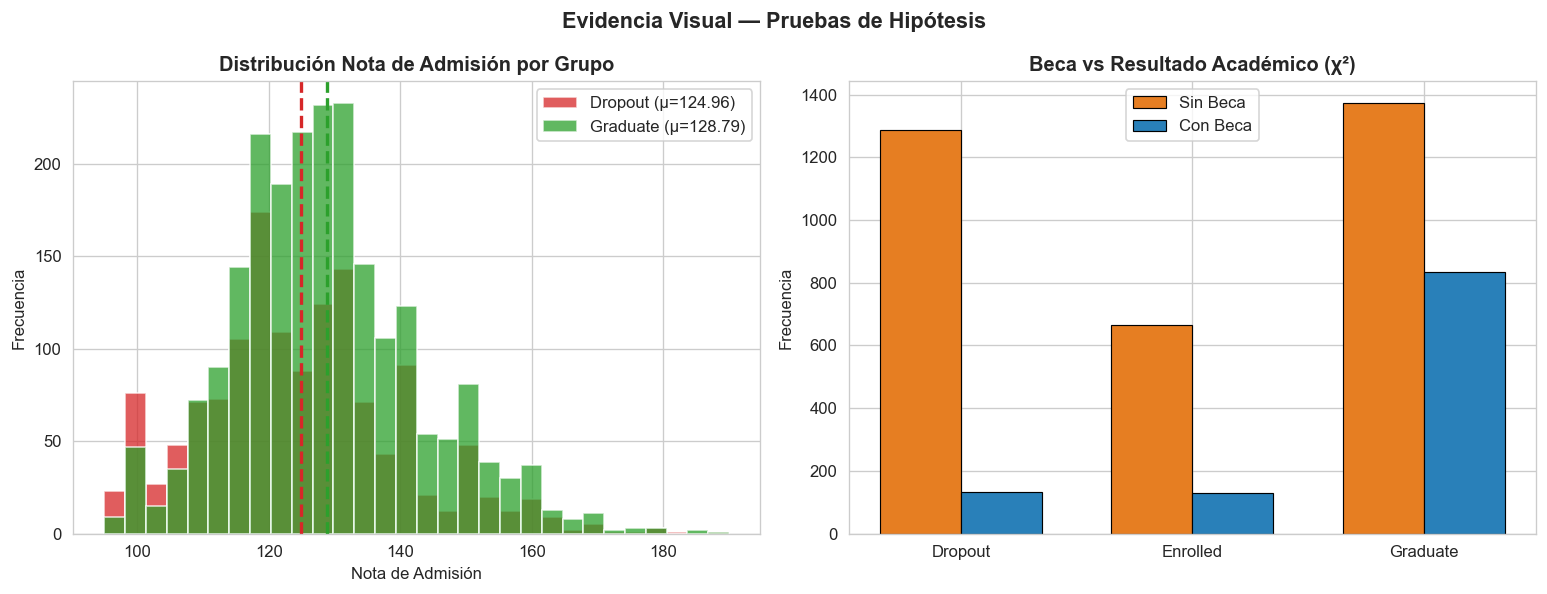

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(dropout_grade, bins=30, alpha=0.75, color=COLORS_TARGET['Dropout'],
             edgecolor='white', label=f'Dropout (μ={dropout_grade.mean():.2f})')
axes[0].hist(grad_grade, bins=30, alpha=0.75, color=COLORS_TARGET['Graduate'],
             edgecolor='white', label=f'Graduate (μ={grad_grade.mean():.2f})')
axes[0].axvline(dropout_grade.mean(), color=COLORS_TARGET['Dropout'], linestyle='--', linewidth=2)
axes[0].axvline(grad_grade.mean(), color=COLORS_TARGET['Graduate'], linestyle='--', linewidth=2)
axes[0].set_title('Distribución Nota de Admisión por Grupo', fontweight='bold')
axes[0].set_xlabel('Nota de Admisión')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Test 2 visual
ct = pd.crosstab(df['Scholarship holder'], df['Target'])
x = np.arange(3)
w = 0.35
ax2 = axes[1]
bar_scheme = ['#e67e22', '#2980b9']
for j, sch in enumerate([0, 1]):
    label = 'Sin Beca' if sch == 0 else 'Con Beca'
    vals = [ct.loc[sch, t] if t in ct.columns else 0
            for t in ['Dropout', 'Enrolled', 'Graduate']]
    ax2.bar(x + j*w, vals, w, label=label, color=bar_scheme[j],
            edgecolor='black', linewidth=0.7)
ax2.set_xticks(x + w/2)
ax2.set_xticklabels(['Dropout', 'Enrolled', 'Graduate'])
ax2.set_title('Beca vs Resultado Académico (χ²)', fontweight='bold')
ax2.set_ylabel('Frecuencia')
ax2.legend()

plt.suptitle('Evidencia Visual — Pruebas de Hipótesis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig7_hipotesis.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretación:** Con t=-7.66 y p<0.001, se rechaza H₀ al nivel α=0.05. Existe evidencia estadística suficiente para concluir que los estudiantes que se gradúan tienen notas de admisión significativamente más altas (μ=128.79) que los que desertan (μ=124.96), con una diferencia de 3.83 puntos sobre una escala de 190.

**Implicancia práctica:** Aunque la diferencia estadística es robusta, su tamaño es relativamente pequeño (d de Cohen ≈ 0.27, efecto pequeño). Esto sugiere que la nota de admisión no es suficiente por sí sola como predictor de abandono, y que intervenciones preventivas basadas únicamente en este criterio tendrían un alcance limitado. Las notas del 1° semestre son un predictor más fuerte y oportuno.

### 4.2 Prueba 2 — ¿Existe asociación entre tener beca y el resultado académico?

**Prueba:** Chi-cuadrado de independencia (χ²)

**Formulación:**
- H₀: La condición de becado y el resultado académico son independientes
- H₁: Existe asociación estadísticamente significativa entre ambas variables

**Nivel de significancia:** α = 0.05

In [17]:
# Tabla de contingencia
ct = pd.crosstab(df['Scholarship holder'], df['Target'],
                 rownames=['Scholarship holder'], colnames=['Target'])

print('=== TABLA DE CONTINGENCIA ===')
print(ct.rename(index={0: 'Sin Beca', 1: 'Con Beca'}))

# Frecuencias relativas por fila
ct_rel = ct.div(ct.sum(axis=1), axis=0) * 100
print('\nFrecuencias relativas por grupo (%)')
print(ct_rel.rename(index={0: 'Sin Beca', 1: 'Con Beca'}).round(1))

# Verificación de supuestos
chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
print(f'\n=== VERIFICACIÓN DE SUPUESTOS ===')
print(f'Frecuencias esperadas mínimas: {expected.min():.2f} (debe ser > 5)')
print(f'Todos los valores esperados ≥ 5: {(expected >= 5).all()}')

# Resultados
print(f'\n=== RESULTADOS ===')
print(f'Chi-cuadrado (χ²) = {chi2:.4f}')
print(f'Grados de libertad = {dof}')
print(f'Valor p            = {p_chi:.2e}')
print(f'\nDecisión: {"RECHAZAR H₀" if p_chi < 0.05 else "NO rechazar H₀"} (α=0.05)')

# Cramér's V (tamaño del efecto)
n = len(df)
k = min(ct.shape)
cramers_v = np.sqrt(chi2 / (n * (k - 1)))
print(f"\nCramér's V = {cramers_v:.4f} (tamaño del efecto: {'pequeño' if cramers_v < 0.3 else 'mediano' if cramers_v < 0.5 else 'grande'})") 

=== TABLA DE CONTINGENCIA ===
Target              Dropout  Enrolled  Graduate
Scholarship holder                             
Sin Beca               1287       664      1374
Con Beca                134       130       835

Frecuencias relativas por grupo (%)
Target              Dropout  Enrolled  Graduate
Scholarship holder                             
Sin Beca               38.7      20.0      41.3
Con Beca               12.2      11.8      76.0

=== VERIFICACIÓN DE SUPUESTOS ===
Frecuencias esperadas mínimas: 197.24 (debe ser > 5)
Todos los valores esperados ≥ 5: True

=== RESULTADOS ===
Chi-cuadrado (χ²) = 409.9431
Grados de libertad = 2
Valor p            = 9.59e-90

Decisión: RECHAZAR H₀ (α=0.05)

Cramér's V = 0.3044 (tamaño del efecto: mediano)


**Interpretación:** Con χ²=409.94 y p<0.001, se rechaza H₀. La condición de becado está significativamente asociada al resultado académico. Los datos muestran que el 76.0% de los becados se gradúan, frente al 41.3% de los no becados. La tasa de abandono entre no becados (38.7%) triplica la de los becados (12.2%).

**Implicancia práctica:** El Cramér's V=0.30 indica un efecto de tamaño moderado. Esto sugiere que las becas constituyen un mecanismo de retención efectivo, no solo un correlato del mérito académico. Desde una perspectiva de política institucional, ampliar la cobertura de becas podría tener un impacto directo y cuantificable en la reducción de la deserción. Sin embargo, se debe considerar que la relación puede ser bidireccional: estudiantes más motivados y con mejor rendimiento también son más propensos a obtener becas.